# Exploratory Data Analysis: US Visa Approval Prediction

This notebook analyzes the EasyVisa dataset (25,480 PERM labor certification records) to understand feature distributions, class imbalance, and relationships between features and approval outcomes.

**Dataset**: Place `EasyVisa.csv` in the project root directory before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

CSV_PATH = "../EasyVisa.csv"
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (25480, 12)


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## 1. Dataset Overview

In [2]:
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

=== Data Types ===
case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object

=== Missing Values ===
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

Total missing: 0


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Feature engineering: company_age
df["company_age"] = date.today().year - df["yr_of_estab"]
df.drop(columns=["case_id", "yr_of_estab"], inplace=True)
print(f"Shape after engineering: {df.shape}")
df.head()

Shape after engineering: (25480, 11)


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


## 2. Target Distribution (Class Imbalance)

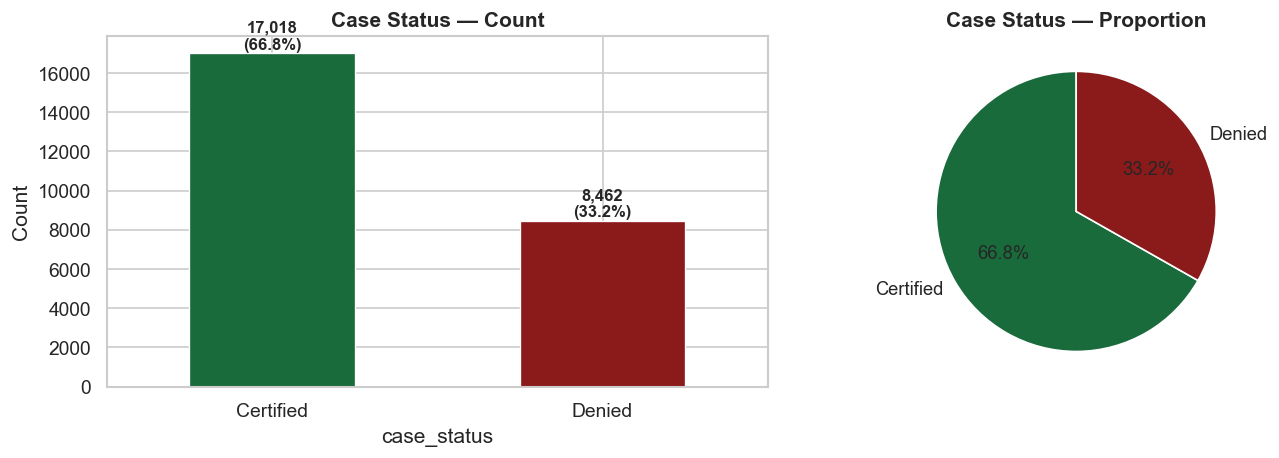


Imbalance ratio: 2.01:1 (Certified:Denied)
A naive 'always Certified' classifier achieves 66.8% accuracy.


In [5]:
counts = df["case_status"].value_counts()
pcts = df["case_status"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#1a6b3c", "#8b1a1a"]
counts.plot.bar(ax=axes[0], color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Case Status — Count", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 200, f"{v:,}\n({p:.1f}%)", ha="center", fontsize=10, fontweight="bold")

axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=colors,
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Case Status — Proportion", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: {counts.iloc[0] / counts.iloc[1]:.2f}:1 (Certified:Denied)")
print(f"A naive 'always Certified' classifier achieves {pcts.iloc[0]:.1f}% accuracy.")

## 3. Categorical Feature Analysis

For each categorical feature, we look at:
1. Distribution of values
2. Certification rate per category

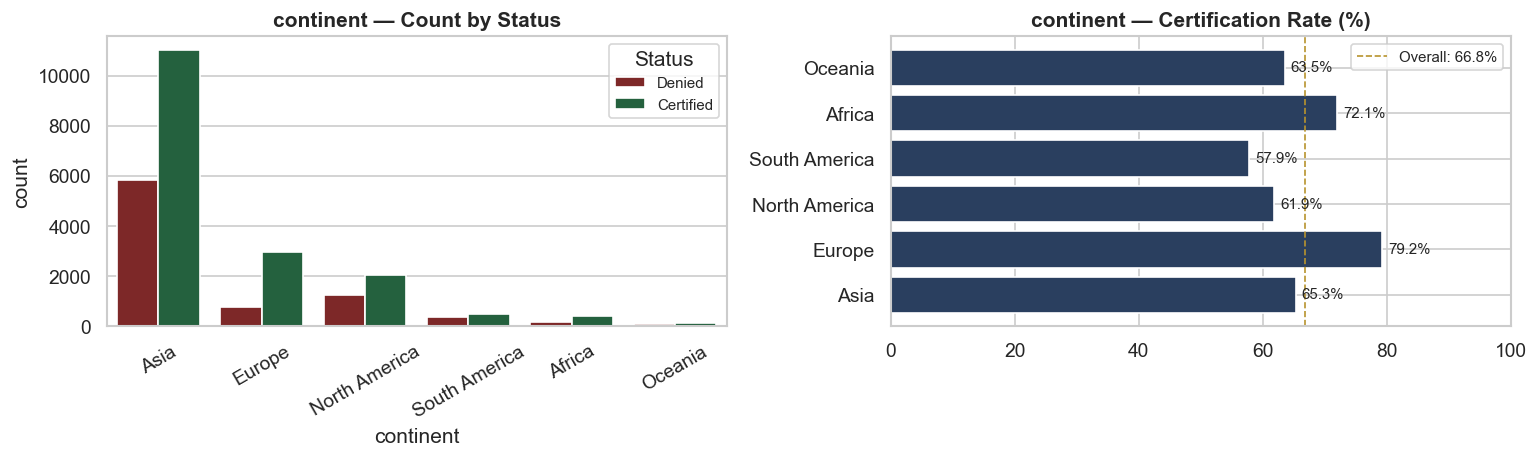

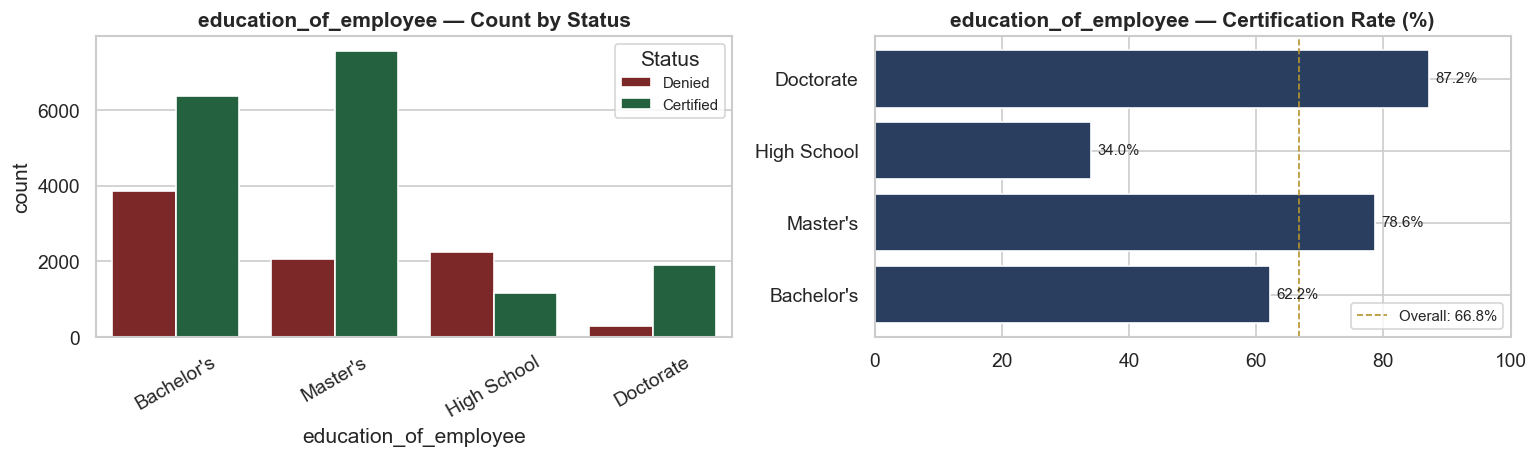

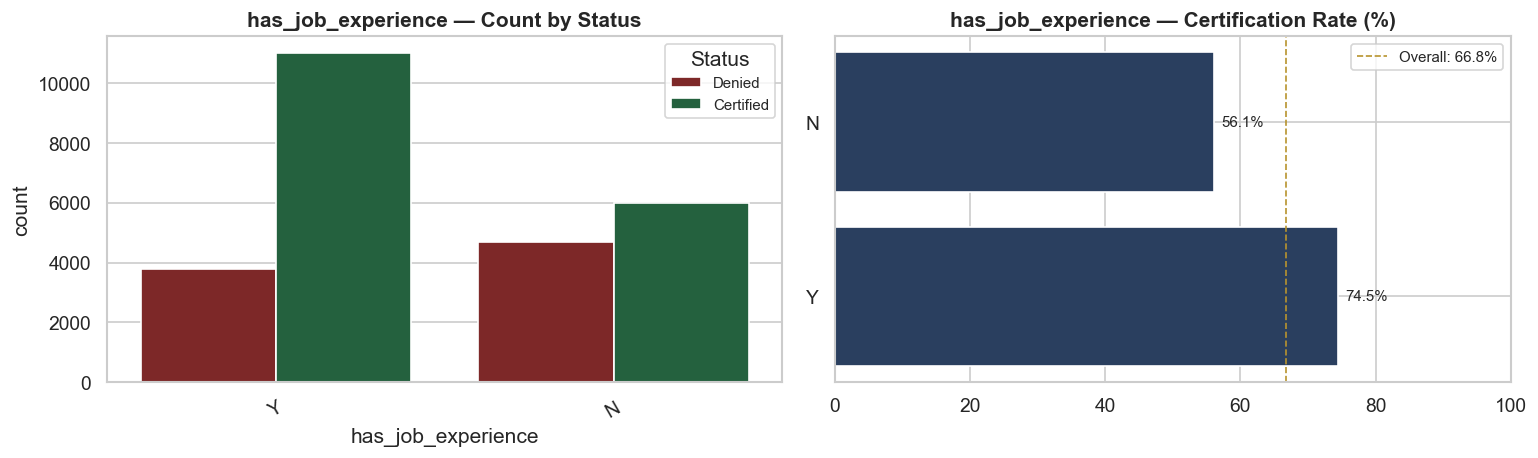

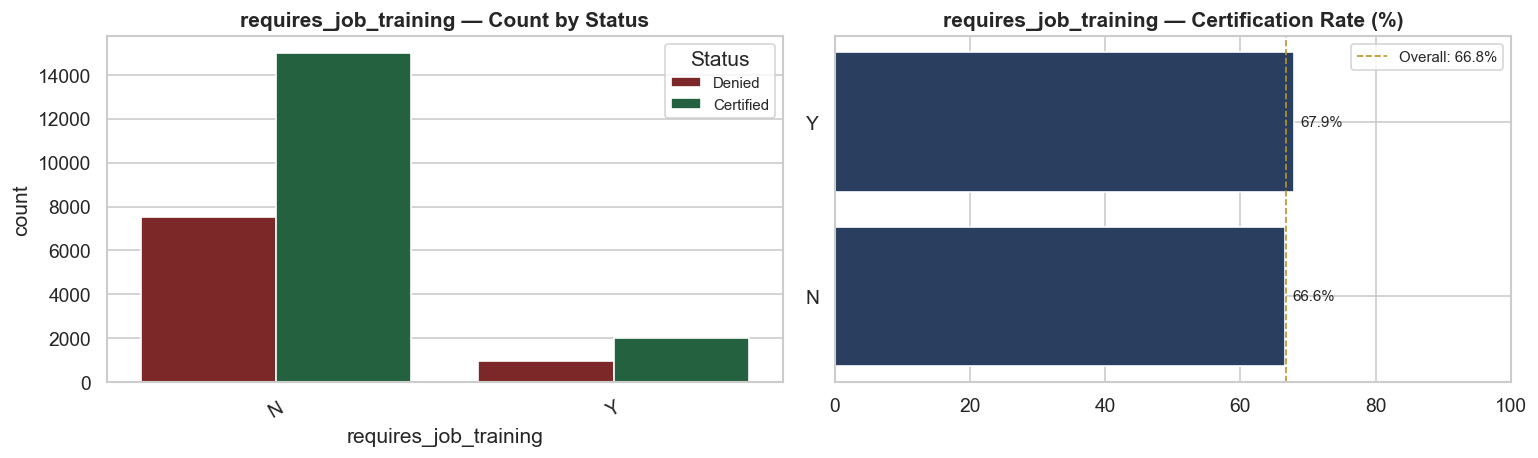

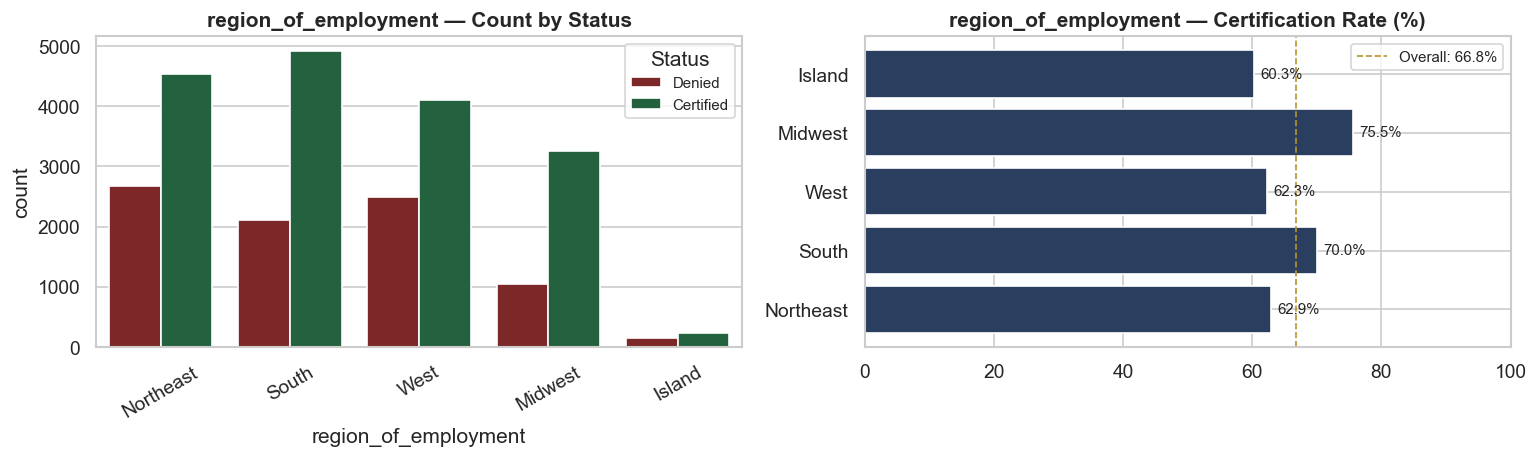

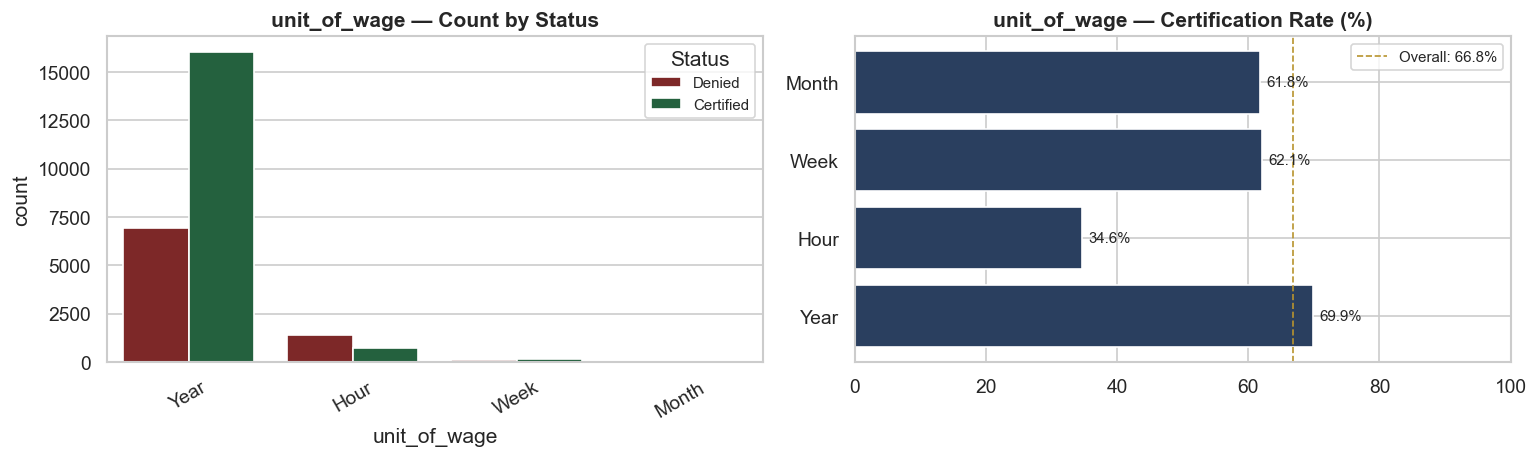

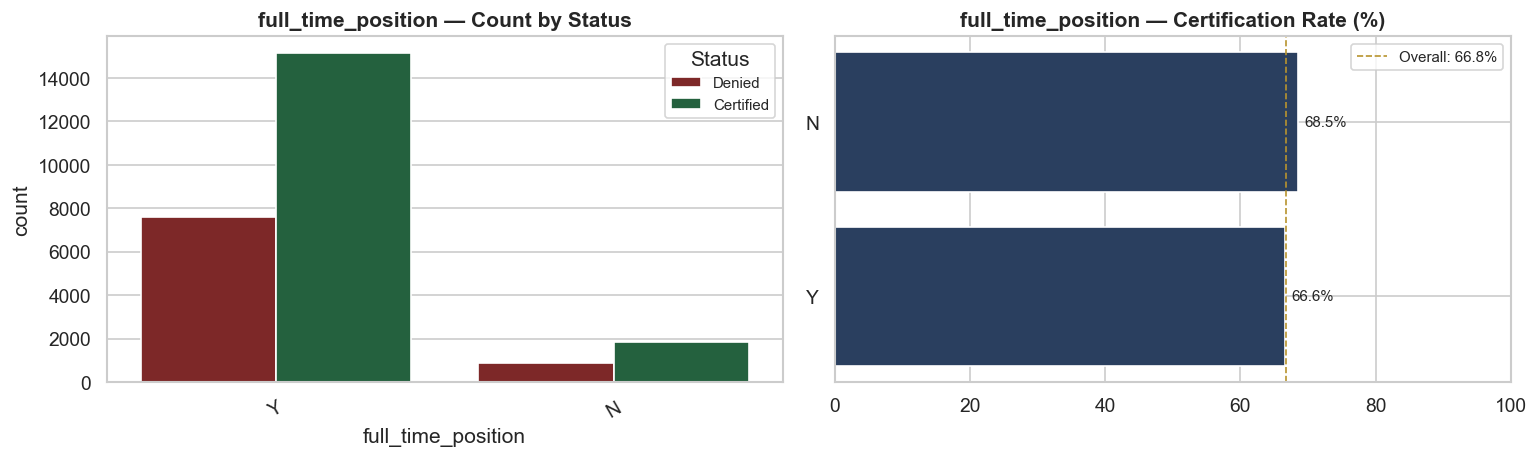

In [6]:
cat_features = ["continent", "education_of_employee", "has_job_experience",
                "requires_job_training", "region_of_employment",
                "unit_of_wage", "full_time_position"]

for feat in cat_features:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Left: count by category
    order = df[feat].value_counts().index
    sns.countplot(data=df, x=feat, hue="case_status", order=order, ax=axes[0],
                  palette={"Certified": "#1a6b3c", "Denied": "#8b1a1a"}, edgecolor="white")
    axes[0].set_title(f"{feat} — Count by Status", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend(title="Status", fontsize=9)

    # Right: certification rate
    cert_rate = (df.groupby(feat)["case_status"]
                 .apply(lambda x: (x == "Certified").mean() * 100)
                 .reindex(order))
    bars = axes[1].barh(cert_rate.index, cert_rate.values, color="#2a3f5f", edgecolor="white")
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f"{feat} — Certification Rate (%)", fontweight="bold")
    axes[1].axvline(x=pcts.iloc[0], color="#b8942e", linestyle="--", linewidth=1, label=f"Overall: {pcts.iloc[0]:.1f}%")
    axes[1].legend(fontsize=9)
    for bar, val in zip(bars, cert_rate.values):
        axes[1].text(val + 1, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

## 4. Numeric Feature Analysis

C:\Users\haris\AppData\Local\Temp\ipykernel_3800\2242569204.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="case_status", y=feat, ax=axes[1],


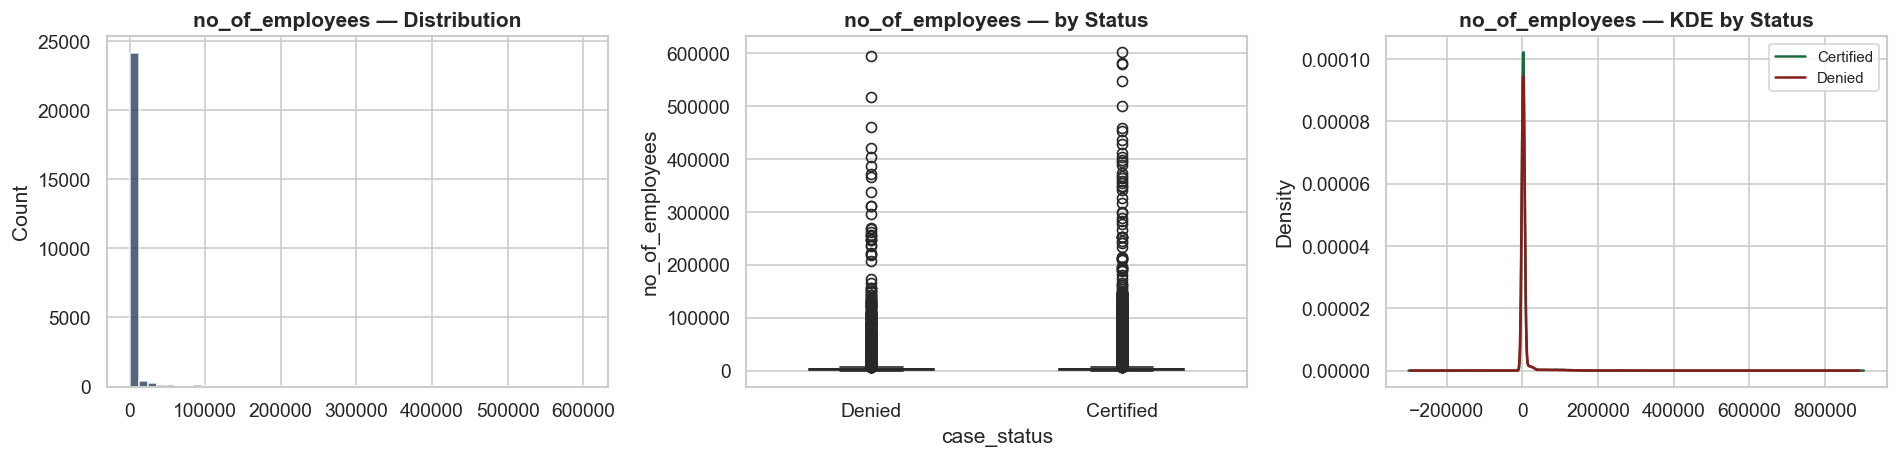


no_of_employees stats:
               count    mean      std   min     25%     50%     75%       max
case_status                                                                  
Certified    17018.0  5807.0  23119.6 -26.0  1035.2  2147.0  3575.0  602069.0
Denied        8462.0  5385.5  22382.8 -26.0   991.0  2032.5  3386.8  594472.0



C:\Users\haris\AppData\Local\Temp\ipykernel_3800\2242569204.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="case_status", y=feat, ax=axes[1],


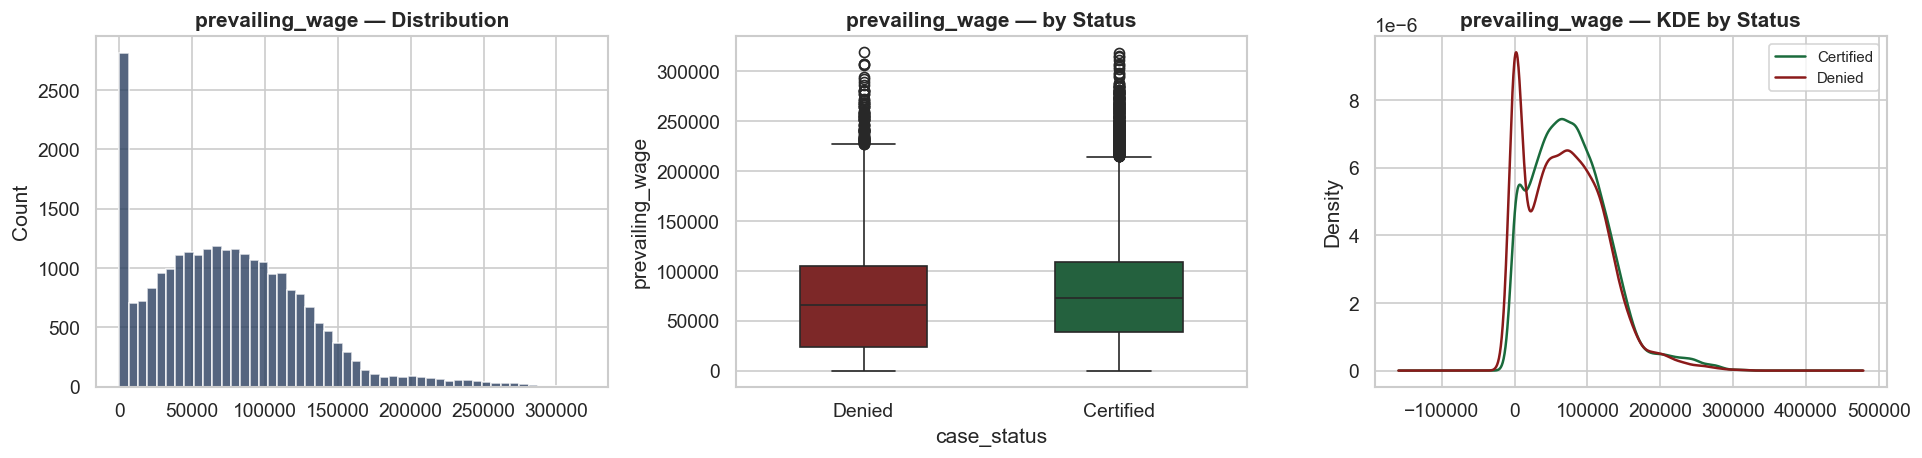


prevailing_wage stats:
               count     mean      std  min      25%      50%       75%  \
case_status                                                               
Certified    17018.0  77293.6  52042.7  2.1  38375.3  72486.3  108879.1   
Denied        8462.0  68748.7  53890.2  3.0  23497.3  65431.5  105097.6   

                  max  
case_status            
Certified    318446.0  
Denied       319210.3  



C:\Users\haris\AppData\Local\Temp\ipykernel_3800\2242569204.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="case_status", y=feat, ax=axes[1],


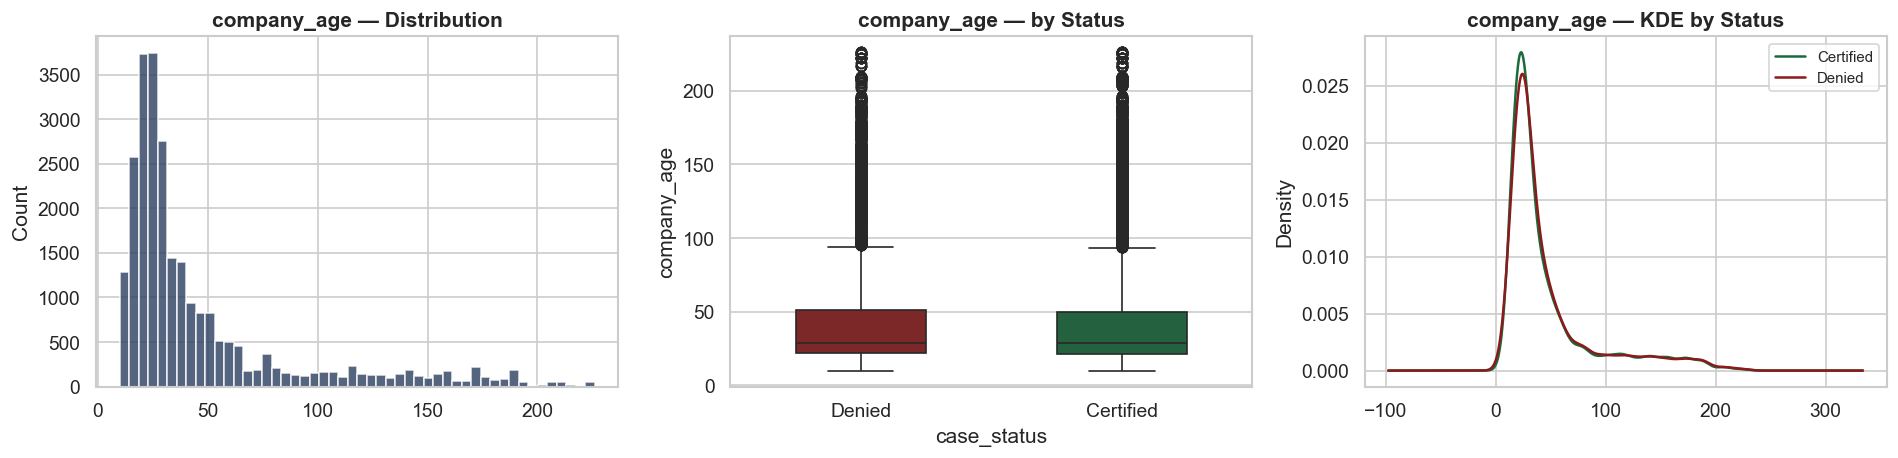


company_age stats:
               count  mean   std   min   25%   50%   75%    max
case_status                                                    
Certified    17018.0  46.3  42.3  10.0  21.0  29.0  50.0  226.0
Denied        8462.0  47.1  42.5  10.0  22.0  29.0  51.0  226.0



In [7]:
num_features = ["no_of_employees", "prevailing_wage", "company_age"]

for feat in num_features:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Distribution
    axes[0].hist(df[feat], bins=50, color="#2a3f5f", edgecolor="white", alpha=0.8)
    axes[0].set_title(f"{feat} — Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")

    # By status (box plot)
    sns.boxplot(data=df, x="case_status", y=feat, ax=axes[1],
                palette={"Certified": "#1a6b3c", "Denied": "#8b1a1a"}, width=0.5)
    axes[1].set_title(f"{feat} — by Status", fontweight="bold")

    # KDE overlay
    for status, color in [("Certified", "#1a6b3c"), ("Denied", "#8b1a1a")]:
        subset = df[df["case_status"] == status][feat].dropna()
        subset.plot.kde(ax=axes[2], label=status, color=color, linewidth=1.5)
    axes[2].set_title(f"{feat} — KDE by Status", fontweight="bold")
    axes[2].legend(fontsize=9)
    axes[2].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"\n{feat} stats:")
    print(df.groupby("case_status")[feat].describe().round(1))
    print()

## 5. Correlation Analysis

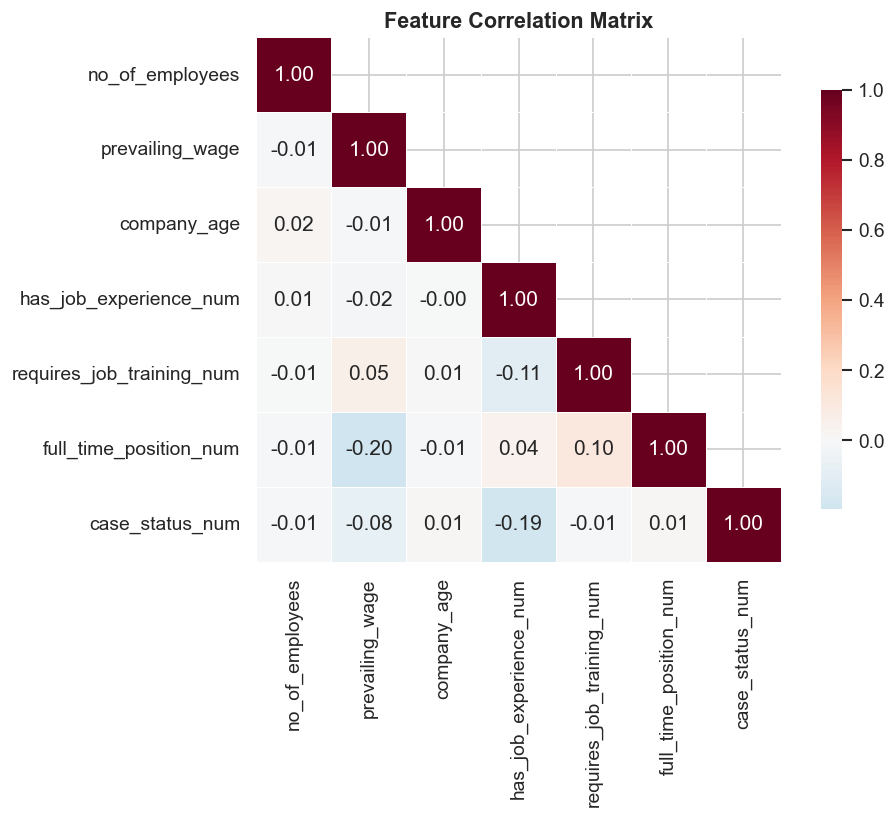


Correlation with Denied (case_status_num):
full_time_position_num       0.013
company_age                  0.009
requires_job_training_num   -0.008
no_of_employees             -0.009
prevailing_wage             -0.076
has_job_experience_num      -0.192
Name: case_status_num, dtype: float64


In [8]:
# Encode target for correlation
df_corr = df.copy()
df_corr["case_status_num"] = (df_corr["case_status"] == "Denied").astype(int)

# Encode binary features
for col in ["has_job_experience", "requires_job_training", "full_time_position"]:
    df_corr[col + "_num"] = (df_corr[col] == "Y").astype(int)

corr_cols = ["no_of_employees", "prevailing_wage", "company_age",
             "has_job_experience_num", "requires_job_training_num",
             "full_time_position_num", "case_status_num"]

corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("\nCorrelation with Denied (case_status_num):")
print(corr_matrix["case_status_num"].drop("case_status_num").sort_values(ascending=False).round(3))

## 6. Wage Analysis by Unit

Prevailing wage varies dramatically based on `unit_of_wage` — a $35/hr wage and a $72,800/yr wage are roughly equivalent. Let's annualize all wages for comparison.

C:\Users\haris\AppData\Local\Temp\ipykernel_3800\1804773271.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cert_by_wage = df.groupby("wage_quartile")["case_status"].apply(lambda x: (x == "Certified").mean() * 100)


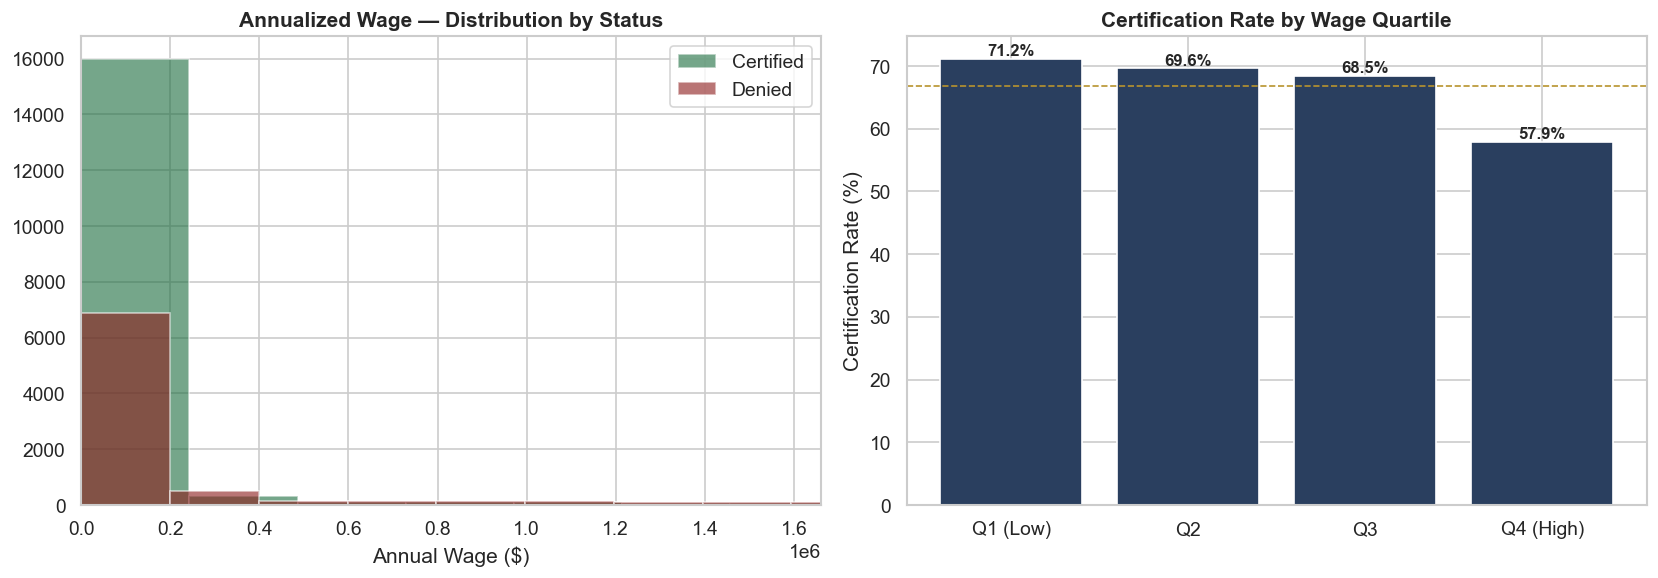

In [9]:
multipliers = {"Hour": 2080, "Week": 52, "Month": 12, "Year": 1}
df["annual_wage"] = df.apply(lambda r: r["prevailing_wage"] * multipliers.get(r["unit_of_wage"], 1), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Annualized wage distribution by status
for status, color in [("Certified", "#1a6b3c"), ("Denied", "#8b1a1a")]:
    subset = df[df["case_status"] == status]["annual_wage"]
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=status, edgecolor="white")
axes[0].set_title("Annualized Wage — Distribution by Status", fontweight="bold")
axes[0].set_xlabel("Annual Wage ($)")
axes[0].legend()
axes[0].set_xlim(0, df["annual_wage"].quantile(0.98))

# Certification rate by wage quartile
df["wage_quartile"] = pd.qcut(df["annual_wage"], q=4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
cert_by_wage = df.groupby("wage_quartile")["case_status"].apply(lambda x: (x == "Certified").mean() * 100)
bars = axes[1].bar(cert_by_wage.index, cert_by_wage.values, color="#2a3f5f", edgecolor="white")
axes[1].set_title("Certification Rate by Wage Quartile", fontweight="bold")
axes[1].set_ylabel("Certification Rate (%)")
axes[1].axhline(y=pcts.iloc[0], color="#b8942e", linestyle="--", linewidth=1)
for bar, val in zip(bars, cert_by_wage.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val:.1f}%",
                 ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

df.drop(columns=["annual_wage", "wage_quartile"], inplace=True)

## 7. Feature Importance Preview

Quick Random Forest to see which features the model considers most important.

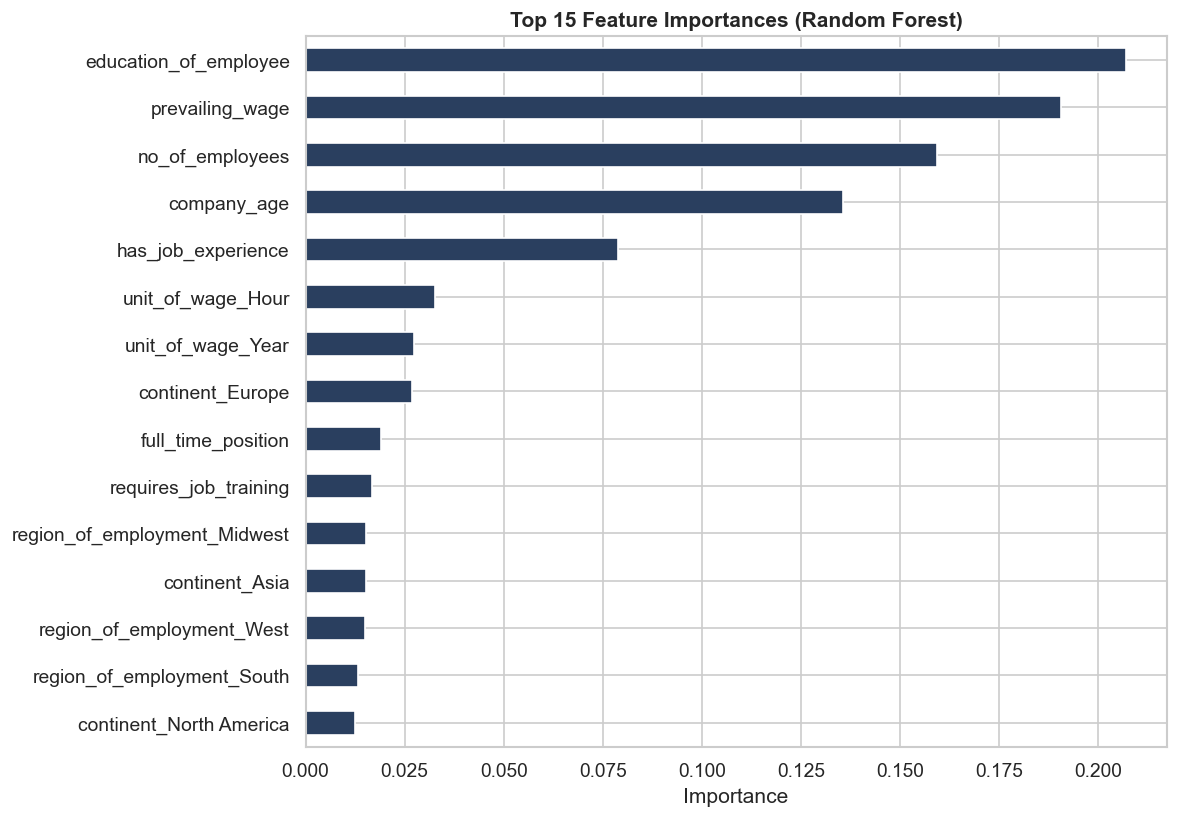

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing (mirrors production pipeline)
preprocessor = ColumnTransformer([
    ("Transformer", PowerTransformer(), ["no_of_employees", "company_age"]),
    ("OrdinalEncoder", OrdinalEncoder(), ["has_job_experience", "requires_job_training",
                                          "full_time_position", "education_of_employee"]),
    ("OneHotEncoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
     ["continent", "unit_of_wage", "region_of_employment"]),
], remainder="passthrough")

X = df.drop(columns=["case_status"])
y = (df["case_status"] == "Denied").astype(int)

X_t = preprocessor.fit_transform(X)

# Build feature names
feat_names = ["no_of_employees", "company_age"]
feat_names += ["has_job_experience", "requires_job_training", "full_time_position", "education_of_employee"]
ohe = preprocessor.named_transformers_["OneHotEncoder"]
feat_names += list(ohe.get_feature_names_out(["continent", "unit_of_wage", "region_of_employment"]))
feat_names += ["prevailing_wage"]  # passthrough

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_t, y)

importances = pd.Series(rf.feature_importances_, index=feat_names[:X_t.shape[1]]).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.tail(15).plot.barh(ax=ax, color="#2a3f5f", edgecolor="white")
ax.set_title("Top 15 Feature Importances (Random Forest)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Key Takeaways

1. **Class imbalance** (66.8% Certified / 33.2% Denied) requires resampling (SMOTEENN) and F1 scoring — accuracy alone is misleading.

2. **Education** has the clearest ordinal relationship with approval. Doctorate > Master's > Bachelor's > High School.

3. **Job experience** and **not requiring training** are strong positive signals.

4. **Prevailing wage** matters — higher wages correlate with certification, especially after annualizing across wage units.

5. **Company size and age** have modest effects. Larger, older companies have slightly better approval rates.

6. **No missing values** — the dataset is clean and ready for modeling without imputation.

7. **Numeric features are skewed** — `no_of_employees` and `company_age` benefit from power transformation before training.